In [3]:
import sklearn
from sklearn.linear_model import LinearRegression

In [8]:
import pandas as pd
import numpy as np
import matplotlib
from matplotlib import pyplot as plt

# Load the Data

In [10]:
df = pd.read_csv("housing.csv")
df_new = pd.read_csv("housing.csv")

## Data Cleaning
##### Exploratory Data Analysis (EDA) => mean, std dev, min, max etc.

what I am seeing when I run df.head() is longitude (which measures where the longitudinal point on the map) the latitude which is measures the latitude. The longitude shows a lot of negative valus, while the laitutde had positive values like 37.88. With the housing_median age, it varies and they are positive. The total rooms are there. the total bedrooms and population as well. There is households (i think the number of people living in a house), the median_income (how much the houses earn). the median_house_value for specific places in the california. The ocean_proximity focuses on how close the house is to the ocean.

In [6]:
df.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


# EDA
#### df.info(), df.describe(), df.isna(), df.isnull()

##### Longitude and Latitude
--- The count is 20,640 for all variables. which represents the entire datapoints for the houses in california.
####################  --- the mean for long is negative likewise all the values, I think the negative means they are below the zero point? The latitude is positive. The std dev for both are close to 2, meaning the values are not widely spread especially for the latitude and the longitutde it can be considered very much spread.
---

# housing_median_age
--- The houses have a mean of 28 yrs showing aged houses. The std. dev is 12yrs which shows the majority of the houses are between (16 - 40yrs) 1 std dev.
--- The max shows 53, the oldest median house age.

# total rooms
--- Then of total rooms is 2632? That's a huge number is it like a hotel or community house? The max bedrooms is 39000.

# total bedrooms
--- The bedrooms for each house is lower than the total rooms. which makes sense. However, the mean is 532? Does it mean some houses have more than 532 bedrooms? I think it has to do with a public facility. The std dev is wide spread thus; 421 bedrooms. The max bedroom is 6445 this means the house with the biggest number of room is 6445
However, the total bedroom count is less than all the variable counts. does it mean the real count is 20433 ?

### Population
--- The mean for the population is 1425 and the std. dev is 1132 which indicates there is a widespread of the population (the number of people living in a specific area or living in one house?) I think its one neighboord because, the max is 35682.

### households
--- Let start with teh Q2 (median) is 280, meaing 280 people in 1 house or neighborhood? The mean is 499 which means for each neighboorhood in Califnoria the average households is close to 500. The std dev is 382, (is it highly spread or low spread) because its lower than the mean , i consider it as low spread. The min is 1 meaning there is 1 household in a community or neighboord?


#### median_income
--- The max is 15.000, does it mean $15 ? or there is 3-4 zeroes that I am not seeing. For the mean (3.8) and std dev (1.9) this spread is low and the values are close.

#### Median house value
--- The mean is 206855$ and std dev is 115395$, this indicate that the values are moderately spread (the value of houses). With a max of 500000$ . One of the houses is as low as 15000$ this might be an outlier maybe.


Considering the wide difference between median income and median house value then there is a problem with the meidan income because its too low or they needs to be an explanation for the value.



The next stage is to check for the distribution of the data; Skewness and/or Kurtosis? If there is anything else for me to check as Data scientist or ML enthusiast let me know.



In [ ]:
df.describe()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.000000,20640.000000,20640.000000,20640.000000,20433.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,-119.569704,35.631861,28.639486,2635.763081,537.870553,1425.476744,499.539680,3.870671,206855.816909
std,2.003532,2.135952,12.585558,2181.615252,421.385070,1132.462122,382.329753,1.899822,115395.615874
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1447.750000,296.000000,787.000000,280.000000,2.563400,119600.000000
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000
75%,-118.010000,37.710000,37.000000,3148.000000,647.000000,1725.000000,605.000000,4.743250,264725.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


## The Corrections on the General Descriptives

 We are dealing with block of houses

### Longitude and Latitude
1) east-west for long, north-south for lat (coordinates)

### housing_median_age
1) mean around 28 years means the typical block group contains houses whose age is near 28 years

### Skewness vs Kurtosis

Skewness as a horizontal shift (leaning left or right) and Kurtosis as a vertical/tail modification (how sharp the peak is and how fat the tails are)

#### Hump on the right (Tail on the left): Left skewed and vice versa

### Relating to the data

Right Tail (High Values): Yes, you are correct. If a neighborhood has a "fat right tail," it means there is an unusually high number of multi-million dollar mansions compared to a normal neighborhood.

Vice Versa
Left Tail (Low Values): Yes, you are correct. A fat left tail means there is a cluster of houses selling for way below the neighborhood average (e.g., foreclosures or fixer-uppers).

Should we interrogate the data? Absolutely. High kurtosis is an automatic signal to look closer. It tells you that standard averages (like the mean) might mislead you because extreme outliers are driving the math.

## Few Checks on the Data

1) Missing values  2) Duplicates  3) Data types  4) Distribution of each feature  5) Skewness   6) Kurtosis




In [11]:
## Missing Values
df.isna().sum()



,0
longitude,0
latitude,0
housing_median_age,0
total_rooms,0
total_bedrooms,207
population,0
households,0
median_income,0
median_house_value,0
ocean_proximity,0


# Skewness

#### for skewness should I plot? Or I should use IQR? to check the tails and outliers?
#### Q3 - Q1 = IQR
#### Q1 - IQR*1.5 (lower outliers)
#### Q3 + IQR*1.5

### To Plot this is what I know

df.plot()

In [8]:
df.dtypes

,0
longitude,float64
latitude,float64
housing_median_age,float64
total_rooms,float64
total_bedrooms,float64
population,float64
households,float64
median_income,float64
median_house_value,float64
ocean_proximity,object


<Axes: >

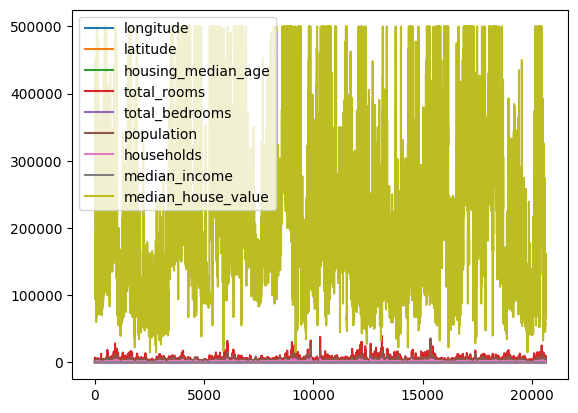

In [ ]:
df.plot() ### When I did this polot, the graph is messy and combined. I cannot see the skeweness or I should use boxplot ?

<Axes: >

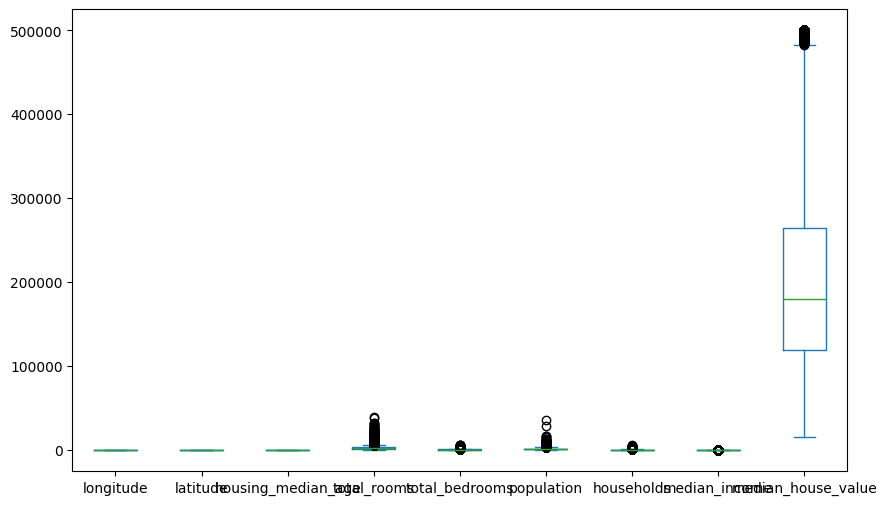

In [ ]:
df.plot(kind='box', figsize=(10,6))

<Axes: >

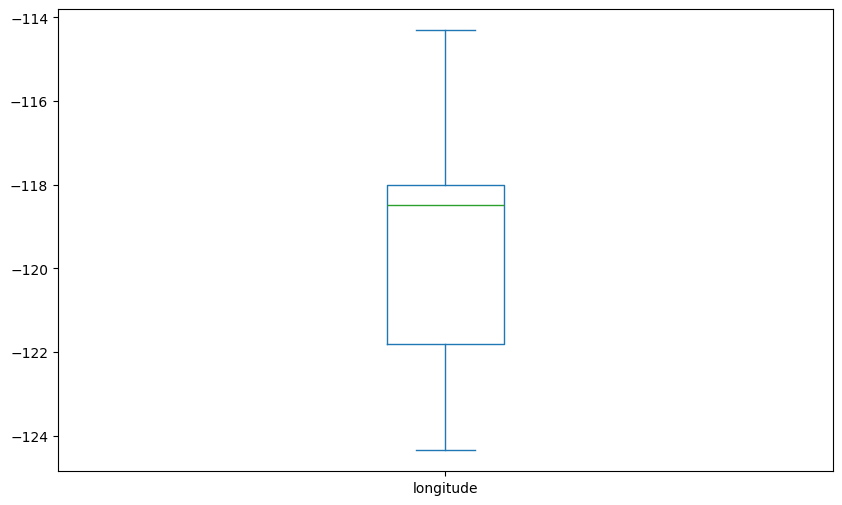

In [ ]:
df['longitude'].plot(kind='box', figsize=(10,6))

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB


<Axes: >

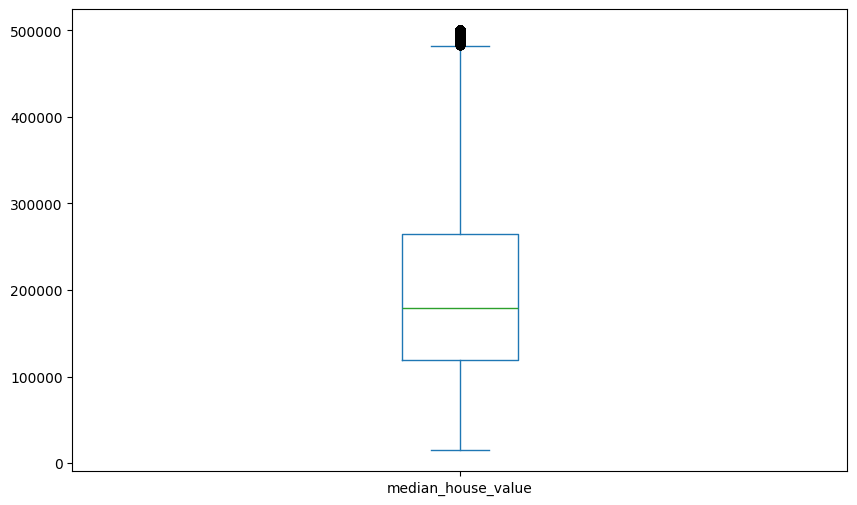

In [ ]:
df['median_house_value'].plot(kind='box', figsize=(10,6))

<Axes: xlabel='[median_house_value]', ylabel='[median_income]'>

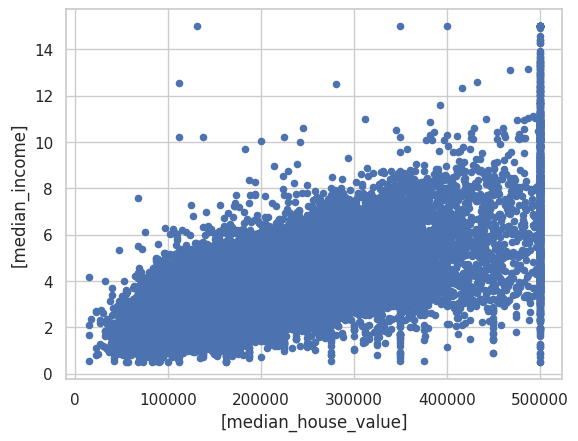

In [12]:
df.plot(kind='scatter', x=['median_house_value'], y=['median_income'])

<Axes: xlabel='housing_median_age', ylabel='median_house_value'>

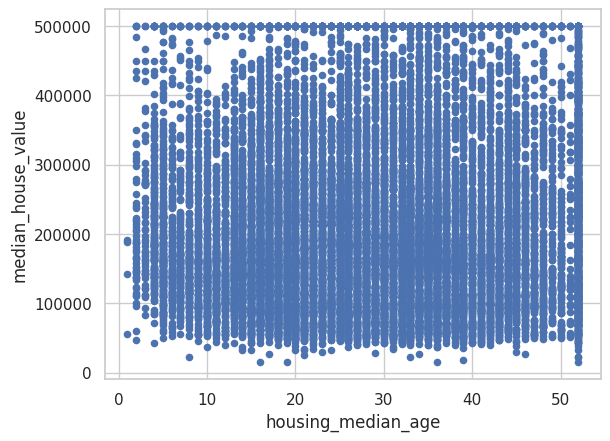

In [13]:
df.plot(kind='scatter', x='housing_median_age', y='median_house_value')

# Problem 1: Identified outliers.
### Normalizing the data to scale. Using Standard scaler from preprocessing

 ##### Solution: 2 options => plot them separately or side by side.

,0
median_income,"Axes(0.125,0.11;0.168478x0.77)"
median_house_value,"Axes(0.327174,0.11;0.168478x0.77)"
households,"Axes(0.529348,0.11;0.168478x0.77)"
population,"Axes(0.731522,0.11;0.168478x0.77)"


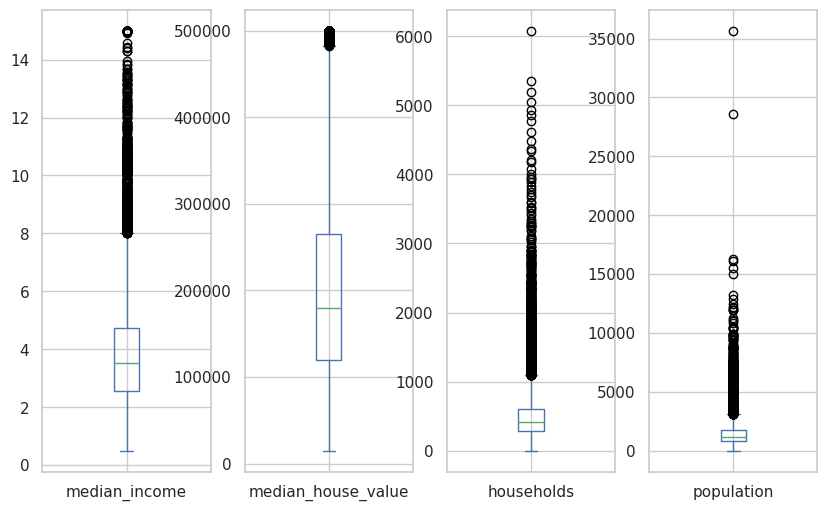

In [14]:
## Side - by - Side plotting (i like this one)

df[['median_income', 'median_house_value', 'households', 'population']].plot(kind='box', subplots=True, figsize=(10, 6))

### After identifying the outliers we have to clean them or rescale them to be able to fit them on the same scale.


##### Min-Max Scaling (Normalization) and Standardization (Z-score scaling) (You can use StandardScaler or RobustScaler).

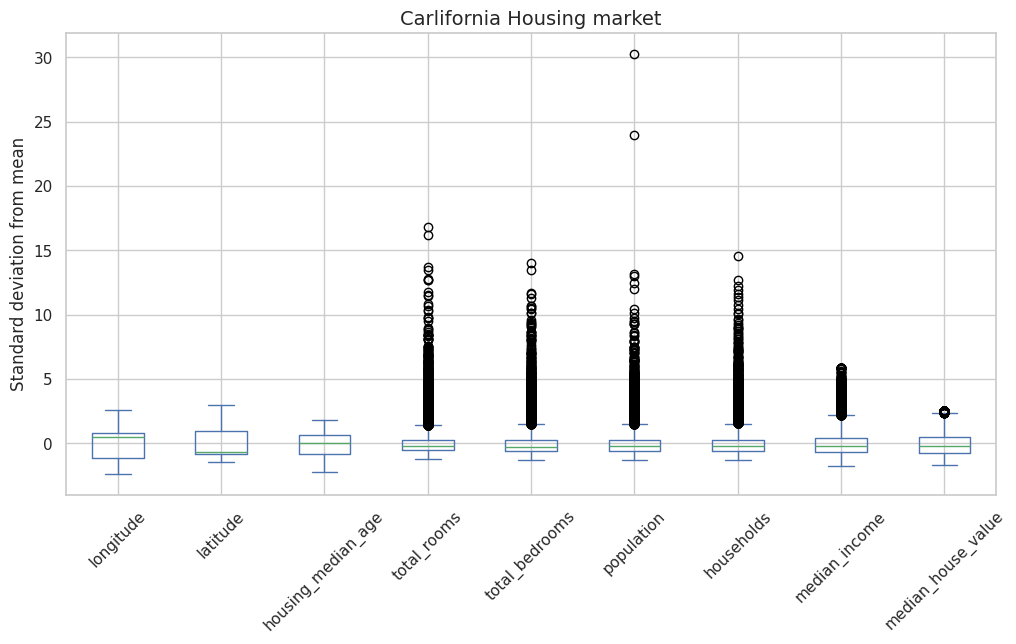

In [15]:
from sklearn.preprocessing import StandardScaler
# Standard

# 1: Get the numeric data
numeric_columns = df.select_dtypes(include=['number'])


# 2: Apply the standardization
scaler = StandardScaler()
standardized_data = scaler.fit_transform(numeric_columns) #fit_transform comes from scaler

# 3: We need the dataframe (add columns)
df_scaled_standard = pd.DataFrame(standardized_data, columns=numeric_columns.columns)
### in the DataFrame use columns

# 3: Plot, label the axis and all
df_scaled_standard.plot(kind='box', figsize=(12, 6), rot=45)
plt.title("Carlifornia Housing market") # title, ylabel, show
plt.ylabel("Standard deviation from mean")
plt.tight_layout
plt.show()


### Deal with the cap on median_house_value

In [16]:
### drop data on value 500k and above

df_cleaned = df[df['median_house_value'] < 500000]

### plot to check if it has dropped

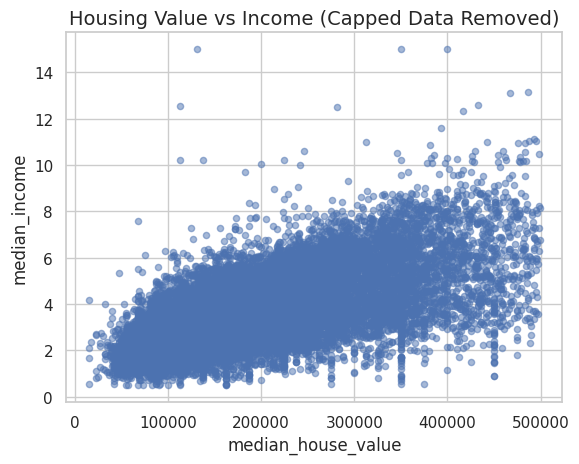

In [17]:
df_cleaned.plot(kind='scatter', x='median_house_value', y='median_income', alpha=0.5)
plt.title("Housing Value vs Income (Capped Data Removed)")
plt.show()

<Axes: xlabel='median_house_value', ylabel='median_income'>

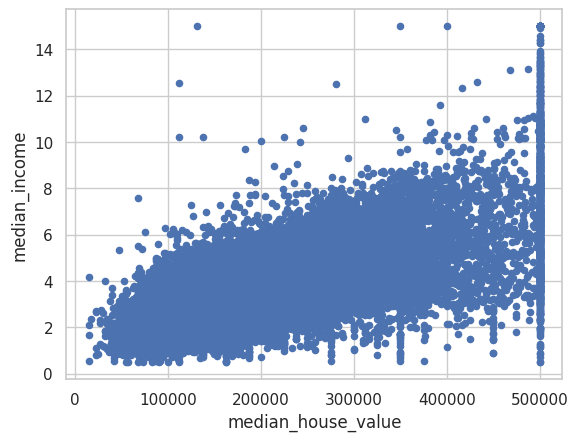

In [18]:
## Compare with the original which was capped

df.plot(kind='scatter', x='median_house_value', y='median_income')

# Problem 1: Too much outliers

### Answer: Try Robust Scaler

In [19]:
from sklearn.preprocessing import RobustScaler
rbt_scaler = RobustScaler()

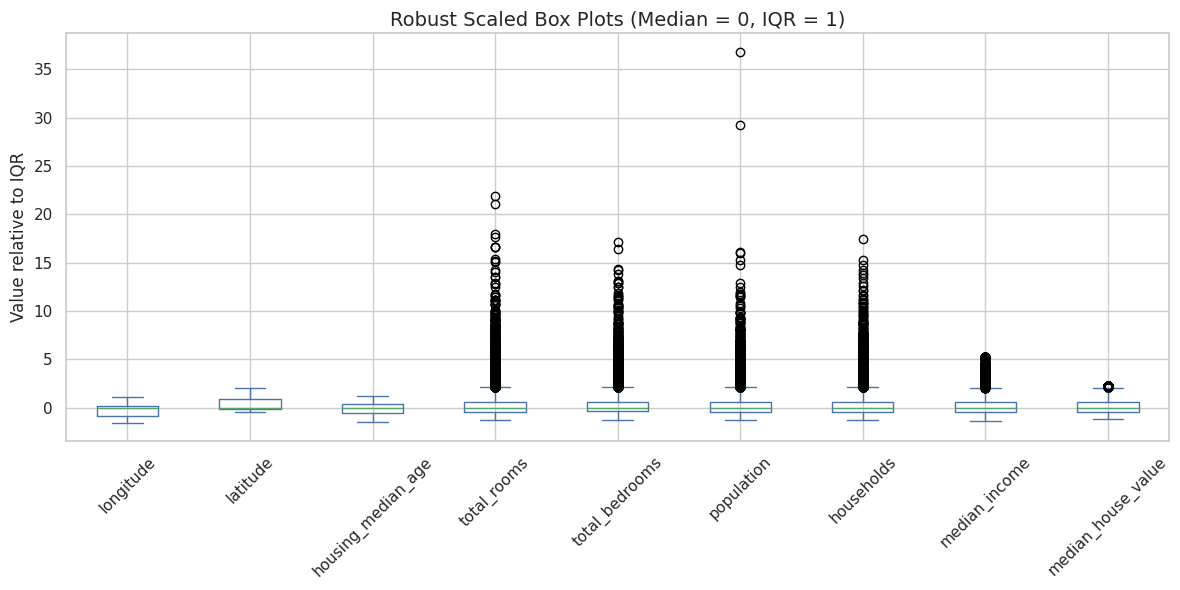

In [20]:
rbt_scaled_data = rbt_scaler.fit_transform(numeric_columns)
data_frame_robust = pd.DataFrame(rbt_scaled_data, columns=numeric_columns.columns)

data_frame_robust.plot(kind='box', figsize=(12,6), rot=45)
plt.title("Robust Scaled Box Plots (Median = 0, IQR = 1)")
plt.ylabel("Value relative to IQR")
plt.tight_layout()
plt.show()

### Population is 30 Standard Deviation up


In [21]:
df['log_population'] = np.log1p(df['population'])

#### Compare them and see the difference

In [22]:
# Show the 10 rows with the smallest population
print(df[['population', 'log_population']].nsmallest(10, 'population'))


       population  log_population
5342          3.0        1.386294
12458         5.0        1.791759
3126          6.0        1.945910
3125          8.0        2.197225
12286         8.0        2.197225
14822         8.0        2.197225
18210         8.0        2.197225
13979         9.0        2.302585
19389         9.0        2.302585
16888        11.0        2.484907


Rerun the robust scaler

<Axes: >

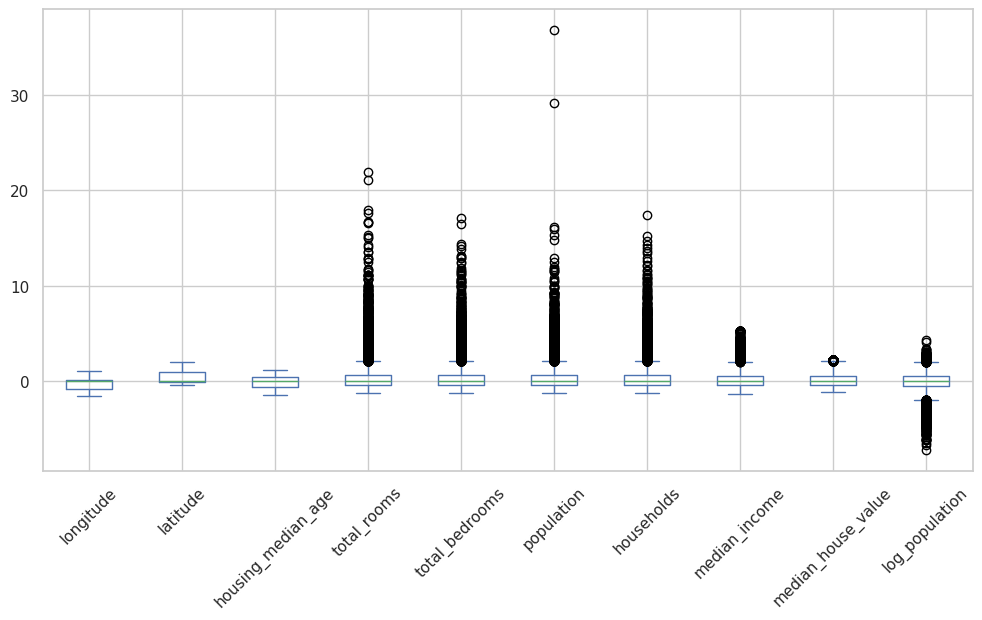

In [23]:
numeric_cols = df.select_dtypes(include=['number'])
scaled_data_robust = rbt_scaler.fit_transform(numeric_cols)


df_transform_robust = pd.DataFrame(scaled_data_robust, columns=numeric_cols.columns)
df_transform_robust.plot(kind='box', figsize=(12, 6), rot=45)

## Check for Skeweness

In [24]:
print(df_transform_robust.skew().sort_values(ascending=False))

population            4.935858
total_rooms           4.147343
total_bedrooms        3.459546
households            3.410438
median_income         1.646657
median_house_value    0.977763
latitude              0.465953
housing_median_age    0.060331
longitude            -0.297801
log_population       -1.044087
dtype: float64


In [25]:
# Drop the population and maintain log_population

df_transform_robust = df_transform_robust.drop(columns=['population'])

In [42]:
df_transform_robust

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,log_population
0,-0.986807,0.957672,0.631579,-0.733422,-0.871795,-0.899787,-0.870769,2.197582,1.880448,-1.638310
1,-0.984169,0.952381,-0.421053,2.924276,1.911681,1.316631,2.243077,2.186664,1.232041,0.920672
2,-0.989446,0.949735,1.210526,-0.388178,-0.698006,-0.714286,-0.713846,1.707732,1.187941,-1.088689
3,-0.992084,0.949735,1.210526,-0.501691,-0.569801,-0.648188,-0.584615,0.967177,1.113523,-0.938753
4,-0.992084,0.949735,1.210526,-0.294074,-0.441595,-0.640725,-0.461538,0.142854,1.119724,-0.922881
...,...,...,...,...,...,...,...,...,...,...
20635,-0.686016,1.380952,-0.210526,-0.271725,-0.173789,-0.342217,-0.243077,-0.905796,-0.700086,-0.410263
20636,-0.717678,1.383598,-0.578947,-0.841053,-0.811966,-0.863539,-0.907692,-0.448655,-0.706977,-1.510663
20637,-0.720317,1.367725,-0.631579,0.074695,0.142450,-0.169510,0.073846,-0.841709,-0.602239,-0.186806
20638,-0.746702,1.367725,-0.578947,-0.157036,-0.074074,-0.453092,-0.184615,-0.765007,-0.654608,-0.577558


<Axes: >

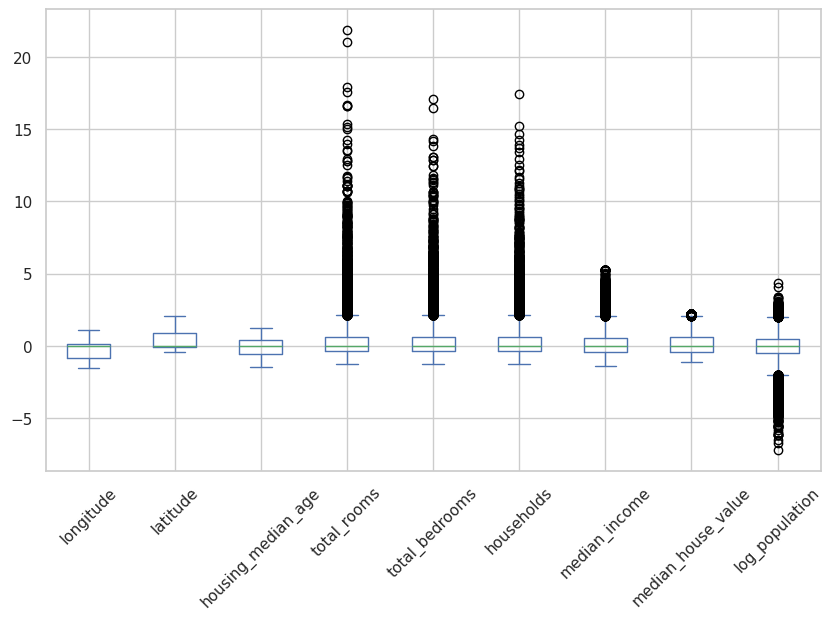

In [26]:
df_transform_robust.plot(kind='box', figsize=(10, 6), rot=45)

# mathematical skewness

In [27]:
print(df_transform_robust.skew().sort_values(ascending=False))

total_rooms           4.147343
total_bedrooms        3.459546
households            3.410438
median_income         1.646657
median_house_value    0.977763
latitude              0.465953
housing_median_age    0.060331
longitude            -0.297801
log_population       -1.044087
dtype: float64


#### Apply log transform to the others

In [28]:
cols = ['households', 'total_rooms', 'total_bedrooms']
for col in cols:
  df_transform_robust[f'log_{col}'] = np.log1p(df_transform_robust[col])

/usr/local/lib/python3.13/dist-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log1p
  result = getattr(ufunc, method)(*inputs, **kwargs)
/usr/local/lib/python3.13/dist-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in log1p
  result = getattr(ufunc, method)(*inputs, **kwargs)
/usr/local/lib/python3.13/dist-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in log1p
  result = getattr(ufunc, method)(*inputs, **kwargs)
/usr/local/lib/python3.13/dist-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log1p
  result = getattr(ufunc, method)(*inputs, **kwargs)
/usr/local/lib/python3.13/dist-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in log1p
  result = getattr(ufunc, method)(*inputs, **kwargs)


In [29]:
df_transform_robust['log_households'].drop

<bound method Series.drop of 0       -2.046156
1        1.176523
2       -1.251226
3       -0.878550
4       -0.619039
           ...   
20635   -0.278494
20636   -2.382628
20637    0.071247
20638   -0.204095
20639    0.316494
Name: log_households, Length: 20640, dtype: float64>

In [30]:
print(df_transform_robust.skew().sort_values(ascending=False))

total_rooms           4.147343
total_bedrooms        3.459546
households            3.410438
median_income         1.646657
median_house_value    0.977763
latitude              0.465953
housing_median_age    0.060331
longitude            -0.297801
log_population       -1.044087
log_total_rooms      -1.179606
log_households             NaN
log_total_bedrooms         NaN
dtype: float64


/usr/local/lib/python3.13/dist-packages/pandas/core/nanops.py:1256: RuntimeWarning: invalid value encountered in subtract
  adjusted = values - mean


In [70]:
df_transform_robust.drop(columns='log_total_rooms', inplace=True)

In [31]:
df_transform_robust

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,households,median_income,median_house_value,log_population,log_households,log_total_rooms,log_total_bedrooms
0,-0.986807,0.957672,0.631579,-0.733422,-0.871795,-0.870769,2.197582,1.880448,-1.638310,-2.046156,-1.322087,-2.054124
1,-0.984169,0.952381,-0.421053,2.924276,1.911681,2.243077,2.186664,1.232041,0.920672,1.176523,1.367182,1.068731
2,-0.989446,0.949735,1.210526,-0.388178,-0.698006,-0.713846,1.707732,1.187941,-1.088689,-1.251226,-0.491314,-1.197347
3,-0.992084,0.949735,1.210526,-0.501691,-0.569801,-0.584615,0.967177,1.113523,-0.938753,-0.878550,-0.696535,-0.843506
4,-0.992084,0.949735,1.210526,-0.294074,-0.441595,-0.461538,0.142854,1.119724,-0.922881,-0.619039,-0.348245,-0.582672
...,...,...,...,...,...,...,...,...,...,...,...,...
20635,-0.686016,1.380952,-0.210526,-0.271725,-0.173789,-0.243077,-0.905796,-0.700086,-0.410263,-0.278494,-0.317076,-0.190905
20636,-0.717678,1.383598,-0.578947,-0.841053,-0.811966,-0.907692,-0.448655,-0.706977,-1.510663,-2.382628,-1.839183,-1.671131
20637,-0.720317,1.367725,-0.631579,0.074695,0.142450,0.073846,-0.841709,-0.602239,-0.186806,0.071247,0.072037,0.133175
20638,-0.746702,1.367725,-0.578947,-0.157036,-0.074074,-0.184615,-0.765007,-0.654608,-0.577558,-0.204095,-0.170831,-0.076961


In [32]:
print(df_transform_robust.skew().sort_values(ascending=False))

total_rooms           4.147343
total_bedrooms        3.459546
households            3.410438
median_income         1.646657
median_house_value    0.977763
latitude              0.465953
housing_median_age    0.060331
longitude            -0.297801
log_population       -1.044087
log_total_rooms      -1.179606
log_households             NaN
log_total_bedrooms         NaN
dtype: float64


/usr/local/lib/python3.13/dist-packages/pandas/core/nanops.py:1256: RuntimeWarning: invalid value encountered in subtract
  adjusted = values - mean


In [73]:
### Loop and apply log

cols = ['total_rooms', 'total_bedrooms', 'households']
for col in cols:
  df_transform_robust[f'log_{col}'] = np.log1p(df_transform_robust[col])

/usr/local/lib/python3.13/dist-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in log1p
  result = getattr(ufunc, method)(*inputs, **kwargs)
/usr/local/lib/python3.13/dist-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log1p
  result = getattr(ufunc, method)(*inputs, **kwargs)
/usr/local/lib/python3.13/dist-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in log1p
  result = getattr(ufunc, method)(*inputs, **kwargs)
/usr/local/lib/python3.13/dist-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log1p
  result = getattr(ufunc, method)(*inputs, **kwargs)
/usr/local/lib/python3.13/dist-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in log1p
  result = getattr(ufunc, method)(*inputs, **kwargs)


In [33]:
df_transform_robust.isnull().sum()

,0
longitude,0
latitude,0
housing_median_age,0
total_rooms,0
total_bedrooms,207
households,0
median_income,0
median_house_value,0
log_population,0
log_households,617


In [34]:
print(df_transform_robust.skew().sort_values(ascending=False))

total_rooms           4.147343
total_bedrooms        3.459546
households            3.410438
median_income         1.646657
median_house_value    0.977763
latitude              0.465953
housing_median_age    0.060331
longitude            -0.297801
log_population       -1.044087
log_total_rooms      -1.179606
log_households             NaN
log_total_bedrooms         NaN
dtype: float64


In [35]:
df_transform_robust.drop(columns='log_total_rooms', inplace=True)

In [36]:
df_transform_robust

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,households,median_income,median_house_value,log_population,log_households,log_total_bedrooms
0,-0.986807,0.957672,0.631579,-0.733422,-0.871795,-0.870769,2.197582,1.880448,-1.638310,-2.046156,-2.054124
1,-0.984169,0.952381,-0.421053,2.924276,1.911681,2.243077,2.186664,1.232041,0.920672,1.176523,1.068731
2,-0.989446,0.949735,1.210526,-0.388178,-0.698006,-0.713846,1.707732,1.187941,-1.088689,-1.251226,-1.197347
3,-0.992084,0.949735,1.210526,-0.501691,-0.569801,-0.584615,0.967177,1.113523,-0.938753,-0.878550,-0.843506
4,-0.992084,0.949735,1.210526,-0.294074,-0.441595,-0.461538,0.142854,1.119724,-0.922881,-0.619039,-0.582672
...,...,...,...,...,...,...,...,...,...,...,...
20635,-0.686016,1.380952,-0.210526,-0.271725,-0.173789,-0.243077,-0.905796,-0.700086,-0.410263,-0.278494,-0.190905
20636,-0.717678,1.383598,-0.578947,-0.841053,-0.811966,-0.907692,-0.448655,-0.706977,-1.510663,-2.382628,-1.671131
20637,-0.720317,1.367725,-0.631579,0.074695,0.142450,0.073846,-0.841709,-0.602239,-0.186806,0.071247,0.133175
20638,-0.746702,1.367725,-0.578947,-0.157036,-0.074074,-0.184615,-0.765007,-0.654608,-0.577558,-0.204095,-0.076961


In [37]:
df_transform_robust['total_bedrooms'] = df_transform_robust['total_bedrooms'].fillna(df_transform_robust['total_bedrooms'].median())

In [38]:
cols = ['total_rooms', 'total_bedrooms', 'households']
for col in cols:
  df_transform_robust[f'log_{col}'] = np.log1p(df_transform_robust[col])

/usr/local/lib/python3.13/dist-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in log1p
  result = getattr(ufunc, method)(*inputs, **kwargs)
/usr/local/lib/python3.13/dist-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log1p
  result = getattr(ufunc, method)(*inputs, **kwargs)
/usr/local/lib/python3.13/dist-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in log1p
  result = getattr(ufunc, method)(*inputs, **kwargs)


In [39]:
print(df_transform_robust.skew().sort_values(ascending=False))

total_rooms           4.147343
total_bedrooms        3.481141
households            3.410438
median_income         1.646657
median_house_value    0.977763
latitude              0.465953
housing_median_age    0.060331
longitude            -0.297801
log_population       -1.044087
log_total_rooms      -1.179606
log_households             NaN
log_total_bedrooms         NaN
dtype: float64


/usr/local/lib/python3.13/dist-packages/pandas/core/nanops.py:1256: RuntimeWarning: invalid value encountered in subtract
  adjusted = values - mean


### Run the Log on the Raw Data first
### Before using the Robust scaler


In [40]:
df_numeric = df.select_dtypes(include=['number'])

print(df_numeric.skew().sort_values(ascending=False))

population            4.935858
total_rooms           4.147343
total_bedrooms        3.459546
households            3.410438
median_income         1.646657
median_house_value    0.977763
latitude              0.465953
housing_median_age    0.060331
longitude            -0.297801
log_population       -1.044087
dtype: float64


In [41]:
cols_df = ['total_rooms', 'total_bedrooms', 'households']
for col in cols_df:
  df_numeric[f'log_{col}'] = np.log1p(df_numeric[col])

In [42]:
print(df_numeric.skew().sort_values(ascending=False))

population            4.935858
total_rooms           4.147343
total_bedrooms        3.459546
households            3.410438
median_income         1.646657
median_house_value    0.977763
latitude              0.465953
housing_median_age    0.060331
longitude            -0.297801
log_total_bedrooms   -0.992813
log_population       -1.044087
log_households       -1.051607
log_total_rooms      -1.075533
dtype: float64


In [43]:
df_numeric.drop(columns=['total_rooms', 'population', 'total_bedrooms', 'households'], inplace=True)

In [44]:
print(df_numeric.skew().sort_values(ascending=False))

median_income         1.646657
median_house_value    0.977763
latitude              0.465953
housing_median_age    0.060331
longitude            -0.297801
log_total_bedrooms   -0.992813
log_population       -1.044087
log_households       -1.051607
log_total_rooms      -1.075533
dtype: float64


<Axes: >

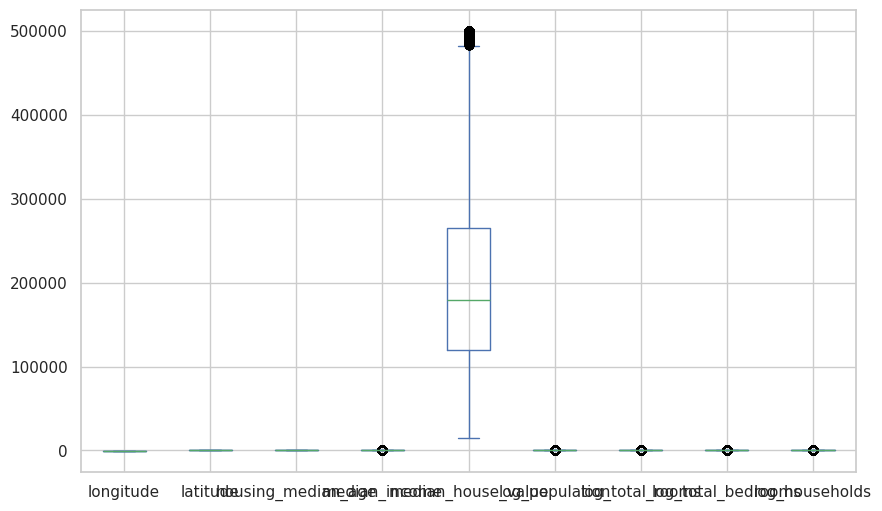

In [45]:
df_numeric.plot(kind='box', figsize=(10, 6))

In [46]:
df_numeric.isnull().sum()

,0
longitude,0
latitude,0
housing_median_age,0
median_income,0
median_house_value,0
log_population,0
log_total_rooms,0
log_total_bedrooms,207
log_households,0


In [48]:
df_numeric['log_total_bedrooms'] = df_numeric['log_total_bedrooms'].fillna(df_numeric['log_total_bedrooms'].median())

In [49]:
df_numeric.isnull().sum()

,0
longitude,0
latitude,0
housing_median_age,0
median_income,0
median_house_value,0
log_population,0
log_total_rooms,0
log_total_bedrooms,0
log_households,0


<Axes: >

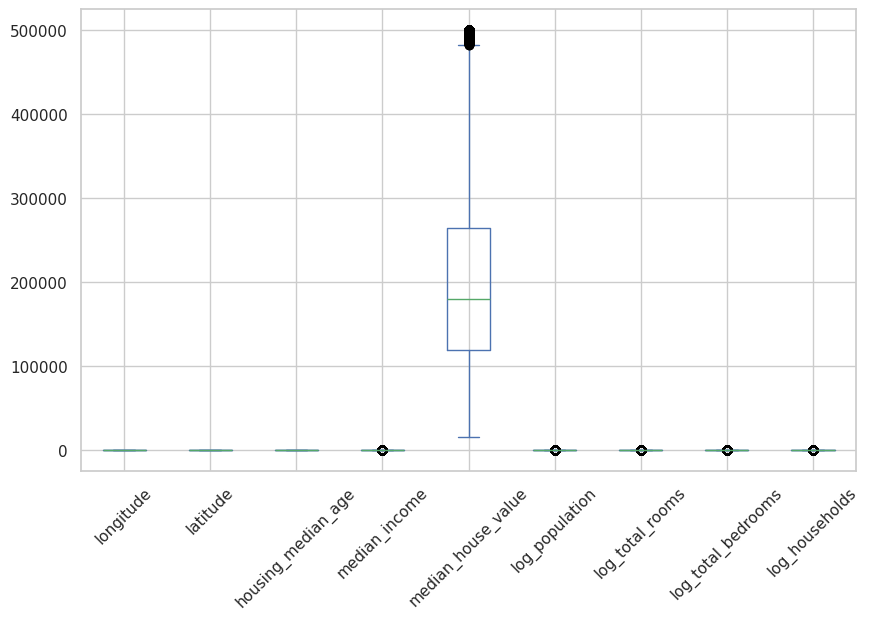

In [50]:
df_numeric.plot(kind='box', figsize=(10, 6), rot=45)

<Axes: >

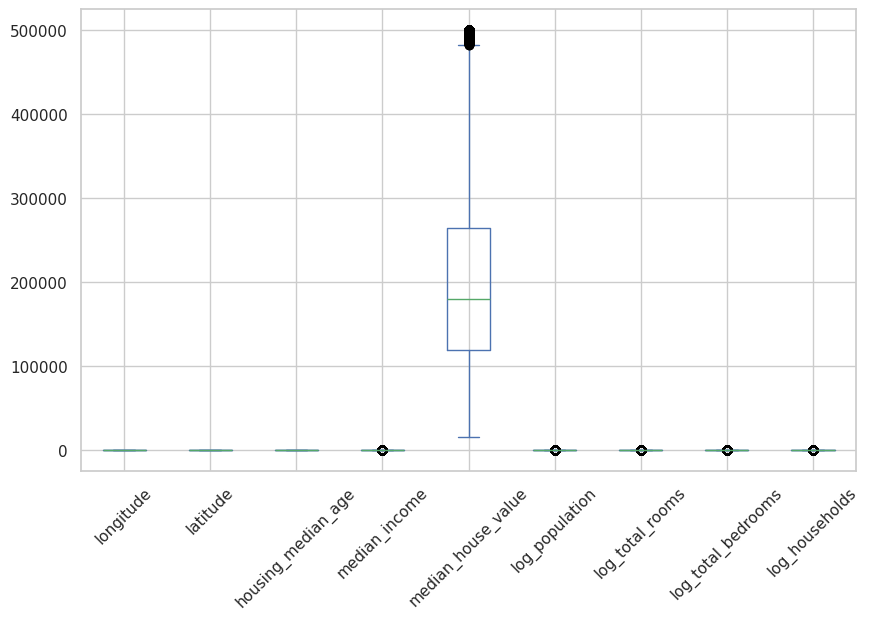

In [51]:
# df_numeric['median_house_value'] = np.log1p(df_numeric['median_house_value'])

# df_numeric.plot(kind='scatter', x= 'median_income', y='median_house_value')

# df_numeric = df_numeric[df_numeric['median_house_value'] < 500000]

df_numeric.plot(kind='box', figsize=(10, 6), rot=45)

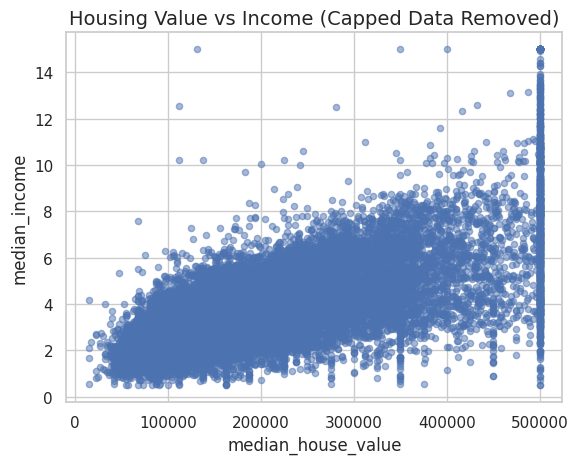

In [52]:
df_numeric.plot(kind='scatter', x='median_house_value', y='median_income', alpha=0.5)
plt.title("Housing Value vs Income (Capped Data Removed)")
plt.show()

In [53]:
## Check the skewness of the raw data
df_new_numeric = df_new.select_dtypes(include='number')
print(df_new_numeric.skew().sort_values(ascending=True))

longitude            -0.297801
housing_median_age    0.060331
latitude              0.465953
median_house_value    0.977763
median_income         1.646657
households            3.410438
total_bedrooms        3.459546
total_rooms           4.147343
population            4.935858
dtype: float64


In [54]:
## Check for missing values
## df_new_numeric.isnull().sum()

## Missing values, Replace with Median value
median_total_bedrooms = df_new_numeric['total_bedrooms'].median()
df_new_numeric['total_bedrooms'] = df_new_numeric['total_bedrooms'].fillna(median_total_bedrooms)


In [55]:
df_new_numeric.isnull().sum()

,0
longitude,0
latitude,0
housing_median_age,0
total_rooms,0
total_bedrooms,0
population,0
households,0
median_income,0
median_house_value,0


In [56]:
print(df_new_numeric.skew().sort_values(ascending=True))

longitude            -0.297801
housing_median_age    0.060331
latitude              0.465953
median_house_value    0.977763
median_income         1.646657
households            3.410438
total_bedrooms        3.481141
total_rooms           4.147343
population            4.935858
dtype: float64


### Introducing Yeo-Johnson compared to Standard Scaler and Robust Scaler

In [57]:
from sklearn.preprocessing import PowerTransformer

columns_to_transform = ['median_house_value', 'median_income', 'households', 'total_bedrooms', 'total_rooms', 'population']
columns_to_keep = ['longitude', 'latitude', 'housing_median_age']

yj_pt = PowerTransformer(method='yeo-johnson')
transformed_array = yj_pt.fit_transform(df_new_numeric[columns_to_transform])

In [58]:
# Rebuild it

# 4. Rebuild the final clean DataFrame

df_transformed = pd.DataFrame(transformed_array, columns=columns_to_transform)

In [59]:
df_transformed.skew().sort_values(ascending=True)

,0
median_house_value,-0.012149
median_income,-0.002538
total_bedrooms,0.107957
households,0.109520
population,0.110641
total_rooms,0.121378


In [61]:
for col in columns_to_keep:
  df_transformed[col] = df_new_numeric[col].values

In [62]:
df_transformed.skew().sort_values(ascending=True)

,0
longitude,-0.297801
median_house_value,-0.012149
median_income,-0.002538
housing_median_age,0.060331
total_bedrooms,0.107957
households,0.109520
population,0.110641
total_rooms,0.121378
latitude,0.465953


### Skewness issue have been solved

### Before and After Distribution Visualization

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns


# Set up a clean, professional aesthetic for GitHub
sns.set_theme(style="whitegrid")



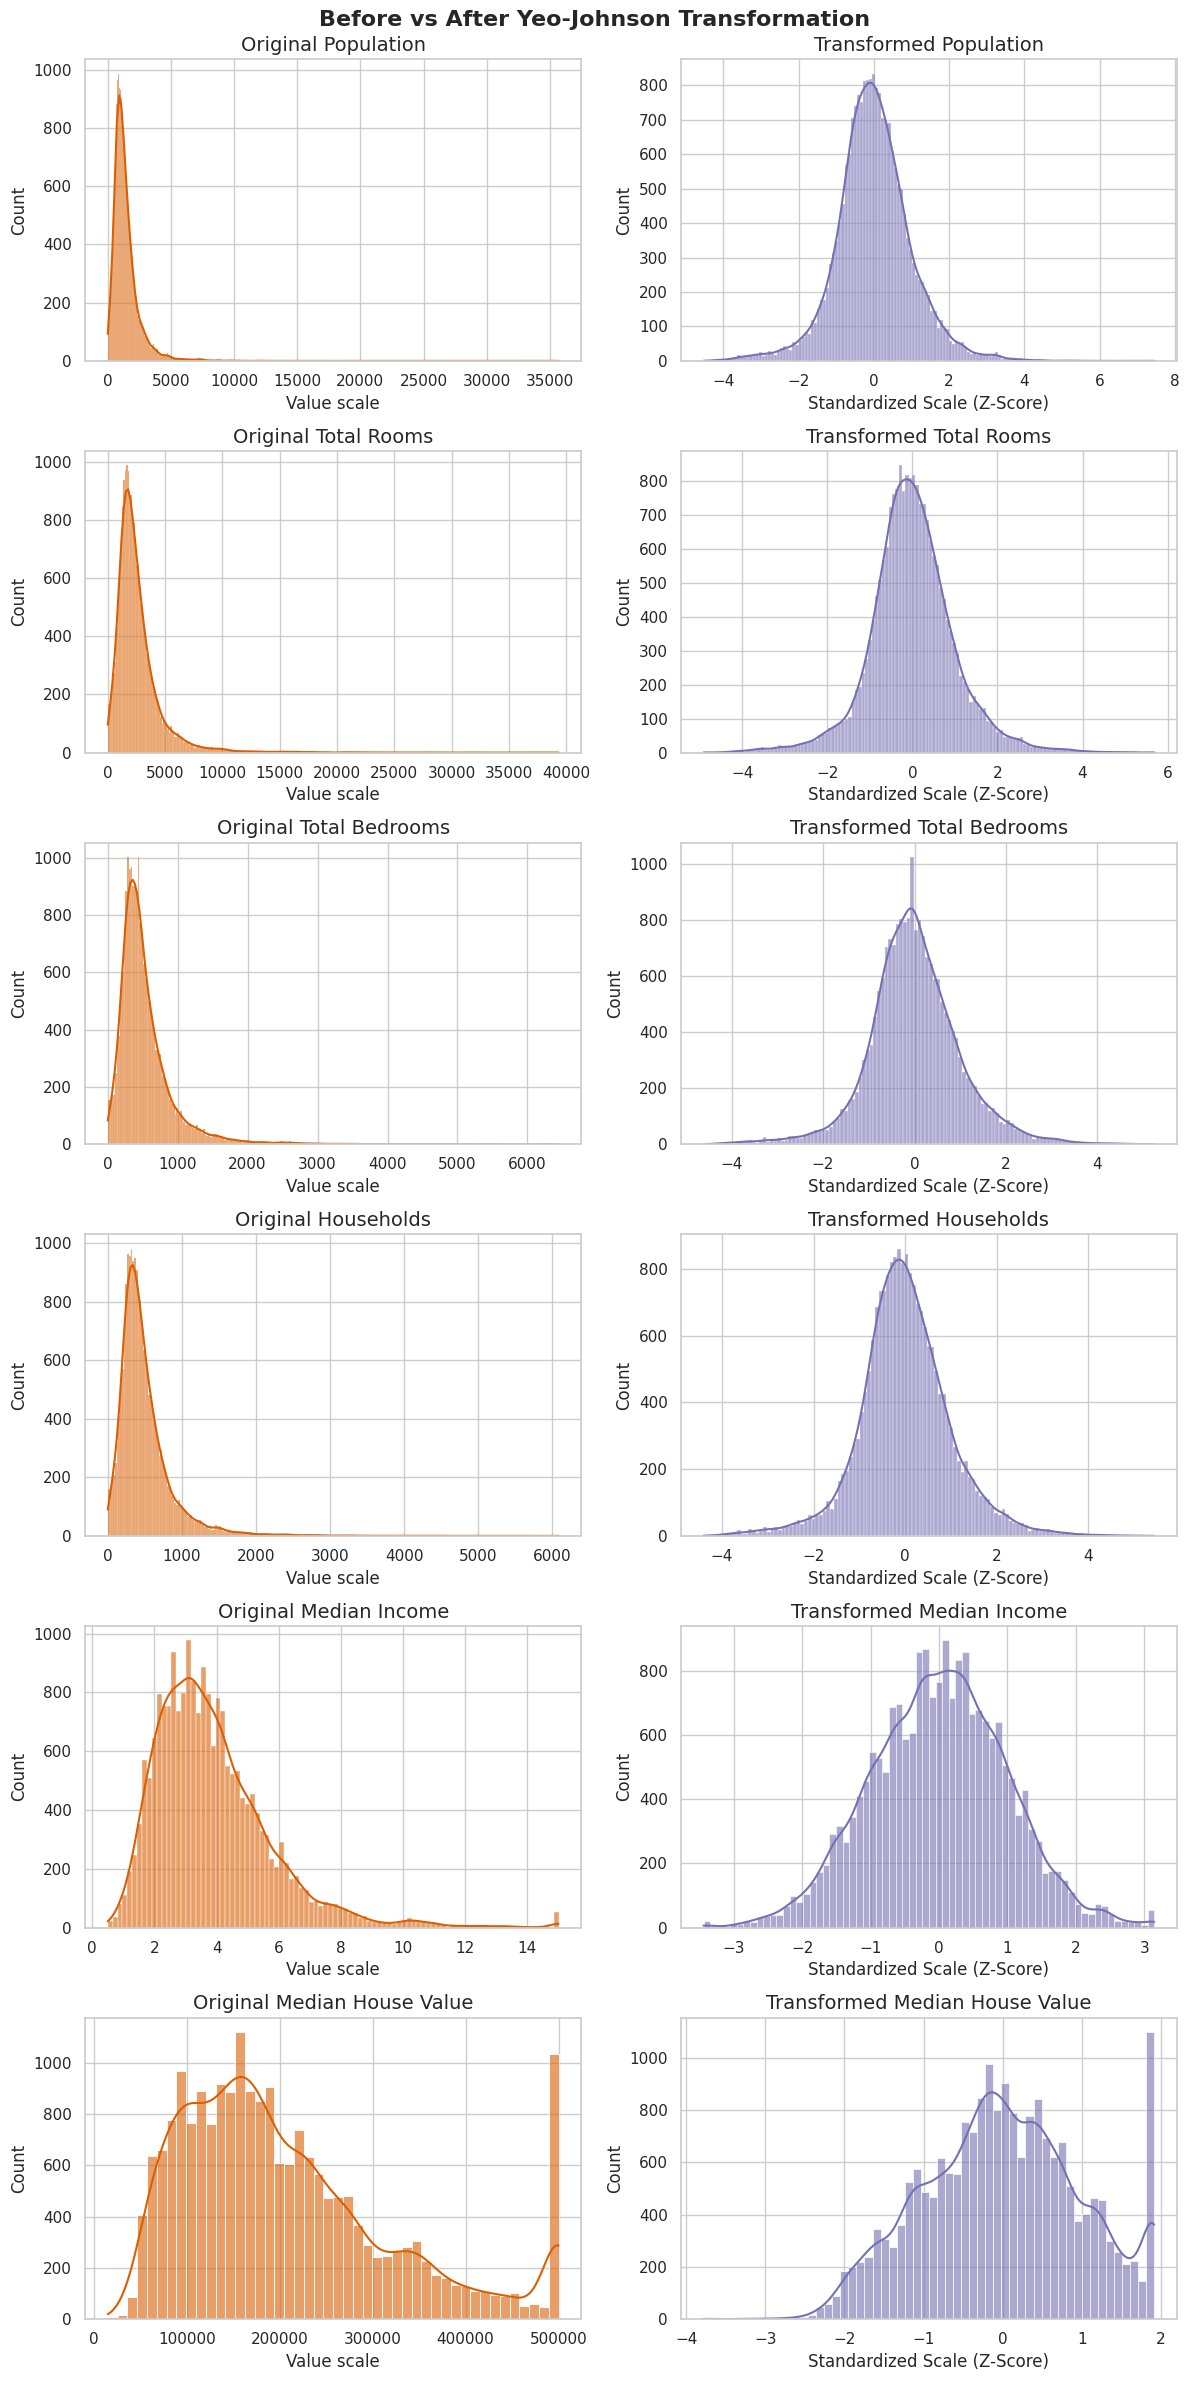

In [63]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set up a clean, professional aesthetic for GitHub
sns.set_theme(style="whitegrid")
plt.rcParams.update({'font.size': 10, 'axes.labelsize': 12, 'axes.titlesize': 14})

# Select the highly skewed features we transformed
skewed_cols = ['population', 'total_rooms', 'total_bedrooms', 'households', 'median_income', 'median_house_value']

# Create a grid of subplots (one row per feature: Raw vs Transformed)
fig, axes = plt.subplots(nrows=len(skewed_cols), ncols=2, figsize=(12, 4 * len(skewed_cols)))
fig.suptitle("Before vs After Yeo-Johnson Transformation", fontsize=16, fontweight='bold', y=0.99)

for i, col in enumerate(skewed_cols):
    # Left Column: Original Raw Data (Heavy Right Skew)
    sns.histplot(df_new_numeric[col], kde=True, ax=axes[i, 0], color='#d95f02', alpha=0.6)
    axes[i, 0].set_title(f"Original {col.replace('_', ' ').title()}")
    axes[i, 0].set_xlabel("Value scale")

    # Right Column: Yeo-Johnson Transformed Data (Symmetric Bell Curve)
    sns.histplot(df_transformed[col], kde=True, ax=axes[i, 1], color='#7570b3', alpha=0.6)
    axes[i, 1].set_title(f"Transformed {col.replace('_', ' ').title()}")
    axes[i, 1].set_xlabel("Standardized Scale (Z-Score)")

# Adjust layout to keep spacing clean and prevent text overlapping
plt.tight_layout()

# Save the plot directly as an asset for your GitHub repository markdown
plt.savefig("data_transformation_results.png", dpi=300, bbox_inches='tight')
plt.show()
